In [1]:
from typing import Annotated
from typing_extensions import TypedDict
import os
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_anthropic import ChatAnthropic
from dotenv import load_dotenv
from IPython.display import Image, display
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import BaseMessage
from langchain_core.tools import tool

In [2]:
load_dotenv()

True

In [3]:
llm = ChatAnthropic(model='claude-sonnet-4-6')
llm

ChatAnthropic(profile={'max_input_tokens': 200000, 'max_output_tokens': 64000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'structured_output': False}, model='claude-sonnet-4-6', max_tokens=64000, anthropic_api_url='https://api.anthropic.com', anthropic_api_key=SecretStr('**********'), model_kwargs={})

In [4]:
os.environ["ANTHROPIC_API_KEY"] = os.getenv("ANTHROPIC_API_KEY")
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "Test_Project"

In [5]:
class State(TypedDict):
    messages:Annotated[list[BaseMessage], add_messages]

In [6]:
@tool
def add(a:float, b:float) -> float:
    """Add 2 Numbers"""
    return a + b

tool_node = ToolNode([add])

llm_w_tools = llm.bind_tools([add])


def call_llm_model(state:State):
    return {"messages":[llm_w_tools.invoke(state["messages"])]}    


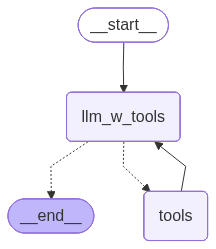

In [7]:
builder = StateGraph(State)
builder.add_node("llm_w_tools", call_llm_model)
builder.add_node("tools", tool_node)

builder.add_edge(START, "llm_w_tools")
builder.add_conditional_edges("llm_w_tools", tools_condition)
builder.add_edge("tools", "llm_w_tools")
builder.add_edge("llm_w_tools", END)
 
graph = builder.compile()

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print("issue")


In [8]:
response = graph.invoke({"messages":"What is Machine Learning?"})
response

{'messages': [HumanMessage(content='What is Machine Learning?', additional_kwargs={}, response_metadata={}, id='7a3580bb-5ae8-4c70-b02c-eabbbf6efe2b'),
  AIMessage(content="## Machine Learning\n\n**Machine Learning (ML)** is a branch of **Artificial Intelligence (AI)** that enables computers to **learn from data and improve their performance over time without being explicitly programmed**.\n\n---\n\n### 🔑 Core Idea\nInstead of writing specific rules for a computer to follow, you feed it **large amounts of data**, and it **finds patterns** and makes decisions on its own.\n\n---\n\n### 📚 Types of Machine Learning\n\n| Type | Description | Example |\n|------|-------------|---------|\n| **Supervised Learning** | Learns from labeled data (input-output pairs) | Spam detection, Image classification |\n| **Unsupervised Learning** | Finds hidden patterns in unlabeled data | Customer segmentation, Clustering |\n| **Reinforcement Learning** | Learns by trial and error using rewards/punishments | 

In [9]:
response = graph.invoke({"messages":"What is 5+20"})
response

{'messages': [HumanMessage(content='What is 5+20', additional_kwargs={}, response_metadata={}, id='a2a3f9b3-1111-41e7-8380-1da2b2b31a8a'),
  AIMessage(content=[{'text': 'I can help you add those numbers!', 'type': 'text'}, {'id': 'toolu_01TtVwBGaLE3f9PJfHz2edx7', 'caller': {'type': 'direct'}, 'input': {'a': 5, 'b': 20}, 'name': 'add', 'type': 'tool_use'}], additional_kwargs={}, response_metadata={'id': 'msg_01Xb8Lf3gX2WtysFXh9NZdvv', 'container': None, 'model': 'claude-sonnet-4-6', 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'global', 'input_tokens': 574, 'output_tokens': 77, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-sonnet-4-6', 'model_provider': 'anthropic'}, id='lc_run--019cf1ec-b856-71a2-9bf6-ada3c3e94721-0', tool_calls=[{'name': 'add', 'args': {'a': 5, 'b': 20}, 'id': '